# Mr.HelpMate AI Project Using LlamaIndex

Note: See the Git Repo for README and details:
https://github.com/avanindra3/generative_doc_search2

## 1. Objectives

The objective of this project is to develop a robust Retrieval-Augmented Generation (RAG) system that automates the process of querying insurance documents. By leveraging large language models (LLMs) and specialized data structures, the system aims to provide accurate, cited, and easy-to-understand answers to user questions.

## 2. Problem Statement

Manually navigating through dense, multi-page insurance policies presents significant challenges for both customers and support agents. The primary issues include:

- **Information Overload:** The sheer volume of text makes it difficult to locate specific clauses quickly.
- **Complexity:** Legalistic and technical language increases the risk of misinterpreting policy coverage, exclusions, and renewal terms.
- **Efficiency:** Manual searches are time-consuming and prone to human error, leading to inconsistent or incorrect answers to critical insurance queries.

### 2.1 Why LlamaIndex?

LlamaIndex was selected as the primary framework for this implementation due to its specialized focus on connecting LLMs with private data. Key advantages include:

- **Modular Architecture:** It allows for easy integration of various components like vector stores (ChromaDB), parsers, and rerankers.
- **Advanced Indexing:** Features like VectorStoreIndex enable efficient semantic search over large datasets.
- **Data Handling:** LlamaIndex excels at processing both structured and unstructured data, ensuring that metadata (like page numbers and policy names) is preserved for accurate citations.

## 3. System Design & Architecture

This RAG (Retrieval-Augmented Generation) system is designed for high-performance document retrieval and precise answering within the insurance domain. The architecture follows an end-to-end pipeline from raw data ingestion to an optimized query response.

### 3.1 End-to-End Flow

1.  **Ingestion Phase**: Documents are loaded from the local `data/` directory using `SimpleDirectoryReader`. These documents are then parsed into smaller, manageable chunks (nodes) via the `SimpleNodeParser` with a defined chunk size and overlap.
2.  **Transformation & Storage**: The `IngestionPipeline` handles transformations, including embedding generation. The resulting nodes and their embeddings are stored in a `ChromaVectorStore`, which is managed via a persistent `ChromaDB` client.
3.  **Retrieval Phase**: When a user submits a query, the `VectorStoreIndex` performs a similarity search to retrieve the top $K$ relevant nodes (initially set to 10).
4.  **Refinement Phase**: Retrieved nodes pass through a reranking layer to ensure the most contextually relevant information is prioritized.
5.  **Generation Phase**: The top reranked nodes and the user query are sent to the LLM (GPT-5-Nano) to generate a final, cited response.

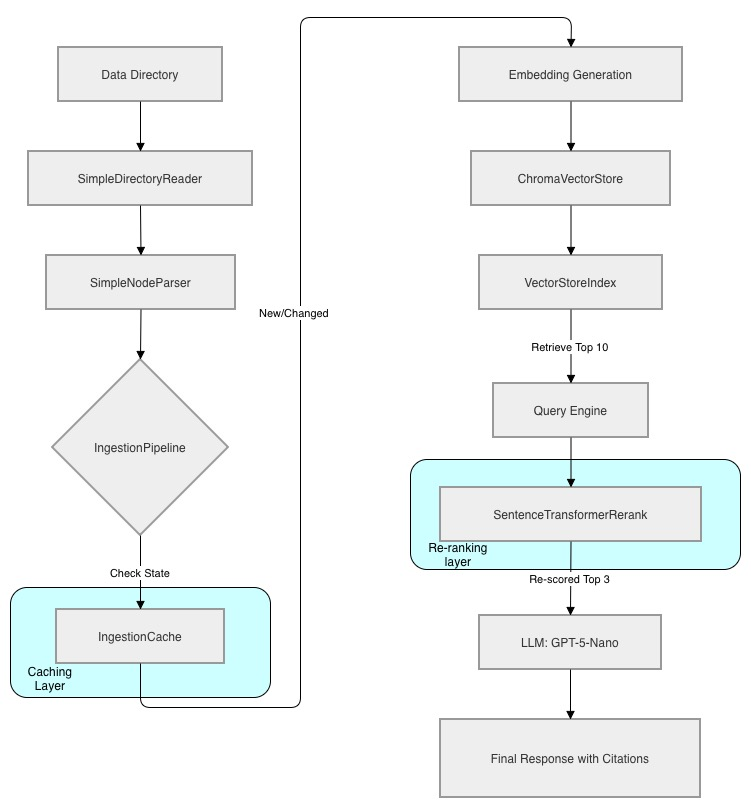

### 3.2 Key Components

*   **IngestionCache**: To optimize resource usage and reduce latency, we implement an `IngestionCache`. This layer tracks the state of processed documents. If a document has not changed since the last run, the pipeline skips re-parsing and re-embedding, significantly reducing API costs and processing time.
*   **SentenceTransformerRerank**: Initial vector retrieval relies on bi-encoders which are fast but can miss nuances. We employ the `cross-encoder/ms-marco-MiniLM-L-6-v2` model in a post-processing step. This reranker evaluates the specific relationship between the query and each retrieved node, re-scoring them to ensure the top 3 nodes passed to the LLM are of the highest possible precision.

## 4. Implementation

In [1]:
import os
import json
import chromadb
from llama_index.core import VectorStoreIndex, SimpleDirectoryReader, StorageContext
from llama_index.core.ingestion import IngestionPipeline, IngestionCache
from llama_index.core.node_parser import SimpleNodeParser
from llama_index.vector_stores.chroma import ChromaVectorStore
from llama_index.core.postprocessor import SentenceTransformerRerank
from llama_index.llms.openai import OpenAI

E0000 00:00:1774180610.099353  182614 instrument.cc:563] Metric with name 'grpc.resource_quota.calls_dropped' registered more than once. Ignoring later registration.
E0000 00:00:1774180610.099382  182614 instrument.cc:563] Metric with name 'grpc.resource_quota.calls_rejected' registered more than once. Ignoring later registration.
E0000 00:00:1774180610.099384  182614 instrument.cc:563] Metric with name 'grpc.resource_quota.connections_dropped' registered more than once. Ignoring later registration.
E0000 00:00:1774180610.099387  182614 instrument.cc:563] Metric with name 'grpc.resource_quota.instantaneous_memory_pressure' registered more than once. Ignoring later registration.
E0000 00:00:1774180610.099388  182614 instrument.cc:563] Metric with name 'grpc.resource_quota.memory_pressure_control_value' registered more than once. Ignoring later registration.


### 4.1 Set OpenAI Key

In [2]:
key = ''
try:
    with open('openai_api_key.json', 'r') as file:
        data = json.load(file)
    key = data['api_key']
except FileNotFoundError:
    print("Error: The file 'data.json' was not found. Please check the file path.")
except json.JSONDecodeError as e:
    print(f"Error: Failed to decode JSON from the file. Details: {e}")

In [3]:
# Set key
os.environ["OPENAI_API_KEY"] = key

### 4.2 Load and chunk document

In [4]:
# Load documents
documents = SimpleDirectoryReader("data").load_data()

2026-03-22 17:26:57,149 - INFO - NumExpr defaulting to 8 threads.


In [5]:
# Document Chunking
parser = SimpleNodeParser.from_defaults(chunk_size=500, chunk_overlap=50)

### 4.3 Initialize Database

In [6]:
# Initialize Chroma client (persistent)
chroma_client = chromadb.PersistentClient(path="./storage")

2026-03-22 17:27:03,654 - INFO - Anonymized telemetry enabled. See                     https://docs.trychroma.com/telemetry for more information.


In [7]:
# Create or get collection
chroma_collection = chroma_client.get_or_create_collection("insurance_rag")

### 4.4 Connect Database to LlamaIndex

In [8]:
# Connect LlamaIndex to Chroma
vector_store = ChromaVectorStore(chroma_collection=chroma_collection)
storage_context = StorageContext.from_defaults(vector_store=vector_store)

### 4.5 Set up caching layer

In [9]:
# SimpleKVStore-based cache prevents re-processing nodes that haven't changed
cache = IngestionCache() 

### 4.6 Set up Ingestion pipeline with Cache

In [10]:
pipeline = IngestionPipeline(
    transformations=[
        parser,
        # LlamaIndex will automatically use default Embeddings here
    ],
    vector_store=vector_store,
    cache=cache)

In [11]:
# Run pipeline: chunks are only generated/embedded if they aren't in cache
nodes = pipeline.run(documents=documents)

### 4.7 Create Database Index

In [12]:
# Create Index from Vector Store
storage_context = StorageContext.from_defaults(vector_store=vector_store)
index = VectorStoreIndex(nodes, storage_context=storage_context)

2026-03-22 17:27:30,531 - INFO - HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"


### 4.8 Load from database if already present

In [7]:
# Load index from vector store if already present
index = VectorStoreIndex.from_vector_store(vector_store)

### 4.9 Initialize Reranker Layer

In [13]:
# Uses a lightweight cross-encoder model to refine results
rerank_postprocessor = SentenceTransformerRerank(
    model="cross-encoder/ms-marco-MiniLM-L-6-v2", 
    top_n=3  # Final number of nodes sent to the LLM
)

/opt/anaconda3/envs/openaienv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### 4.10 Configure LLM

In [14]:
llm_system_prompt = "You are a helpful assistant in the insurance domain who can effectively answer user queries about insurance policies and documents."

In [15]:
# Use gpt-5-nano
llm = OpenAI(model="gpt-5-nano", system_prompt=llm_system_prompt)

### 4.11 Configure Query Engine

In [16]:
# Build Query Engine with Reranking
query_engine = index.as_query_engine(
    llm=llm,
    similarity_top_k=10,  # Retrieve more nodes initially for the reranker to evaluate
    node_postprocessors=[rerank_postprocessor]
)

### 4.12 Query the RAG

In [17]:
def get_llm_query(query):
    llm_query_full = f"""You have a question asked by the user in '{query}' and you have some search results from a corpus of insurance documents. These search results are essentially one page of an insurance document that may be relevant to the user query.
    Use the documents to answer the query '{query}'. Frame an informative answer and also, use the dataframe to return the relevant policy names and page numbers as citations.
    
    Follow the guidelines below when performing the task.
    1. Try to provide relevant/accurate numbers if available.
    2. You don’t have to necessarily use all the information in the dataframe. Only choose information that is relevant.
    3. If the document text has tables with relevant information, please reformat the table and return the final information in a tabular in format.
    3. Use the Metadatas columns in the dataframe to retrieve and cite the policy name(s) and page numbers(s) as citation.
    4. If you can't provide the complete answer, please also provide any information that will help the user to search specific sections in the relevant cited documents.
    5. You are a customer facing assistant, so do not provide any information on internal workings, just answer the query directly.
    
    The generated response should answer the query directly addressing the user and avoiding additional information. If you think that the query is not relevant to the document, reply that the query is irrelevant. Provide the final response as a well-formatted and easily readable text along with the citation. Provide your complete response first with all information, and then provide the citations.
    """
    return llm_query_full

In [18]:
def get_response(query):
    llm_query = get_llm_query(query)
    response = query_engine.query(llm_query)
    return response

#### 4.12.1 Query 1

In [19]:
query_1 = "How can I renew my policy?"

In [20]:
response = get_response(query_1)

2026-03-22 17:27:58,788 - INFO - HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
Batches: 100%|████████████████████████████████████| 1/1 [00:00<00:00,  5.77it/s]
2026-03-22 17:28:14,252 - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


In [21]:
print(response.response)

 renewal is described as an annual process.

- How renewal works: The policy is renewed automatically each Policy Anniversary while the Group Policy remains in force. Renewal occurs at the premium rates that are in effect on the Policy Anniversary.

- Where this is described: Part II - Policy Administration, Section D - Policy Renewal, Article 1 - Renewal.

Citations:
- Principal-Sample-Life-Insurance-Policy.pdf, Page 25 (Section D - Policy Renewal, Article 1 - Renewal)


#### 4.12.2 Query 2

In [22]:
query_2 = "Do I have to submit any medical report to apply for insurance?"

In [23]:
response = get_response(query_2)

2026-03-22 17:28:24,696 - INFO - HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
Batches: 100%|████████████████████████████████████| 1/1 [00:00<00:00, 19.39it/s]
2026-03-22 17:28:49,776 - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


In [24]:
print(response.response)

Answer:
- If you are applying for a Dependent Life Insurance individual policy, you will not be required to submit Proof of Good Health (no medical report needed) to apply.
- If you are applying under the Group Policy, Proof of Good Health may be required to start initial insurance in certain cases. The policy notes specific situations where Proof of Good Health is required and describes the process and timing (“Effective Date for Initial Insurance When Proof of Good Health is Required”).

Citations:
- Principal-Sample-Life-Insurance-Policy.pdf, Page 43
- Principal-Sample-Life-Insurance-Policy.pdf, Page 29
- Principal-Sample-Life-Insurance-Policy.pdf, Page 28


#### 4.12.3 Query 3

In [25]:
query_3 = "Will I have insurance cover if I travel outside the country?"

In [26]:
response = get_response(query_3)

2026-03-22 17:29:03,600 - INFO - HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
Batches: 100%|████████████████████████████████████| 1/1 [00:00<00:00, 19.49it/s]
2026-03-22 17:29:24,492 - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


In [27]:
print(response.response)

Yes. You can maintain coverage while you are temporarily outside the United States, but it depends on your reason for being abroad and you must pay the premiums. Specifically:

- You may continue your insurance for up to six months for one of the following reasons:
  - Travel
  - A business assignment
  - Full-time student status (with conditions: you are either enrolled and attending an accredited school in a foreign country, or you are participating in an academic program in a foreign country for which your U.S. institution grants academic credit)

- The six-month period is not reduced by any time covered under a Prior Policy.

- If you are outside the United States for any other reason not listed above, your coverage will automatically terminate.

For more details, see the coverage rules in the policy sections that cover outside-the-U.S. coverage and terminations.

Citations:
- Principal-Sample-Life-Insurance-Policy.pdf — Page 36-37


## 5. Challenges

Building a RAG system for the insurance domain presented several unique challenges:
1. **Complexity of Legal Language**: Insurance policies contain dense, legalistic language that can be difficult for standard embedding models to parse effectively without fine-tuned context.
2. **PDF Structural Integrity**: Extracting data from large, multi-page PDFs with varying layouts (tables, headers, and footers) often results in fragmented context if chunking strategies are not precisely tuned.
3. **API Latency**: Integrating sophisticated reranking layers and high-parameter LLMs (like GPT-5-nano) introduces latency, which requires a balance between retrieval precision and system responsiveness.
4. **Data Accuracy and Hallucination**: Ensuring the model cites specific page numbers and policy names correctly is critical in a compliance-heavy industry where incorrect information can have legal implications.

## 6. Lessons Learnt

1. **Reranking for Precision**: The implementation of `SentenceTransformerRerank` proved vital. Initial retrieval (`similarity_top_k=10`) often captures noise; however, the cross-encoder model effectively filters this down to the most relevant nodes, significantly increasing the signal-to-noise ratio in the final LLM prompt.
2. **Optimization via IngestionCache**: Using `IngestionCache` is essential for iterative development. It prevents redundant embedding and processing of documents that haven't changed, saving both time and API costs during the data ingestion pipeline.
3. **Structured Prompting**: Providing a highly structured system prompt for the insurance domain helps the LLM maintain a professional persona and adhere to strict formatting rules (like tabular output for policy comparisons).